In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random

In [2]:
class CarEnv:
    def __init__(self):
        self.m = 1000.0
        self.dt = 0.1
        self.force_scale = 1000.0
        self.target = 10.0
        self.x = 0.0
        self.v = 0.0
        self.previous_distance = 0.0
        self.current_distance = 0.0
        self.error = self.target - self.x

    def reset(self):
        self.x = 0.0
        self.v = 0.0
        return np.array([self.x, self.v])
    
    def step(self, action):

        self.previous_distance = abs(self.target - self.x)

        F = action * self.force_scale
        a = F / self.m
        self.v = self.v + a * self.dt
        self.x = self.x + self.v * self.dt
        self.error = self.target - self.x

        self.current_distance = abs(self.target - self.x)

        next_state = np.array([self.x, self.v])
        reward = (self.previous_distance - self.current_distance)
        done = self.x >= self.target

        return next_state, reward, done

In [3]:
env = CarEnv()
state = env.reset()

In [4]:
def discretize_state(state):
    x_bin = int(state[0])
    v_bin = int(state[1])

    return (x_bin, v_bin)

def get_q_values(Q, state):
    if state not in Q:
        Q[state] = [0.0, 0.0, 0.0]

    return Q[state]

def select_action(Q, state, epsilon):
    actions = [-1, 0, 1]

    if random.random() < epsilon:
        action = np.random.choice(actions)

        return action

    else:
        q_values = get_q_values(Q, state)
        best_index = q_values.index(max(q_values))
        action = actions[best_index]

        return action

def update_q(Q, state, action, reward, next_state, alpha, gamma):

    actions = [-1, 0, 1]
    action_idx = actions.index(action)

    Q[state][action_idx] += alpha * (reward + gamma * max(Q[next_state]) - Q[state][action_idx])


In [5]:
def update_q(Q, state, action, reward, next_state, alpha, gamma):

    q_values = get_q_values(Q, state)
    next_q_values = get_q_values(Q, next_state)

    actions = [-1, 0, 1]
    action_idx = actions.index(action)

    q_values[action_idx] += alpha * (
        reward
        + gamma * max(next_q_values)
        - q_values[action_idx]
    )

In [6]:
Q = {}

num_episodes = 100
max_steps = 300

alpha = 0.1
gamma = 0.95
epsilon = 0.1

In [7]:
times = []
positions = []
velocities = []
actions = []
rewards = []

In [8]:
for episode in range(num_episodes):
    state = env.reset()

    for step in range(max_steps):
        discrete_state = discretize_state(state)

        action = select_action(Q, discrete_state, epsilon)

        next_state, reward, done = env.step(action)

        discrete_next_state = discretize_state(next_state)

        update_q(Q, discrete_state, action, reward, discrete_next_state, alpha, gamma)

        state = next_state

        if done:
            break

In [9]:
len(Q)

22

In [10]:
list(Q.items())[:10]

[((0, 0),
  [np.float64(1.4304920798278395),
   np.float64(1.392873283242461),
   np.float64(1.633536632659573)]),
 ((0, 1),
  [np.float64(1.6299336081566296),
   np.float64(0.6652564590248145),
   np.float64(0.5148576851900581)]),
 ((1, 1),
  [np.float64(1.8510686497316013),
   np.float64(1.0545466729046404),
   np.float64(1.2504887392198536)]),
 ((1, 0),
  [np.float64(1.1747583378685225),
   np.float64(1.1991558126276256),
   np.float64(1.8554222759649974)]),
 ((2, 0),
  [np.float64(1.3683821142919392),
   np.float64(1.3029578745856412),
   np.float64(1.8459541660654912)]),
 ((2, 1),
  [np.float64(1.838062183228402),
   np.float64(1.2913192987634603),
   np.float64(1.391242422129975)]),
 ((3, 0),
  [np.float64(1.4130941101729018),
   np.float64(1.315574180361543),
   np.float64(1.8152592224610138)]),
 ((4, 1),
  [np.float64(1.761164095780415),
   np.float64(1.3183460235047606),
   np.float64(1.119081688333877)]),
 ((4, 0),
  [np.float64(1.0219383988798434),
   np.float64(1.2612817701

In [11]:
state = env.reset()

times = []
positions = []
velocities = []
actions_log = []
rewards = []

for step in range(max_steps):
    discrete_state = discretize_state(state)

    action = select_action(Q, discrete_state, epsilon=0.0)

    next_state, reward, done = env.step(action)

    times.append(step * env.dt)
    positions.append(state[0])
    velocities.append(state[1])
    actions_log.append(action)
    rewards.append(reward)

    state = next_state

    if done:
        pass

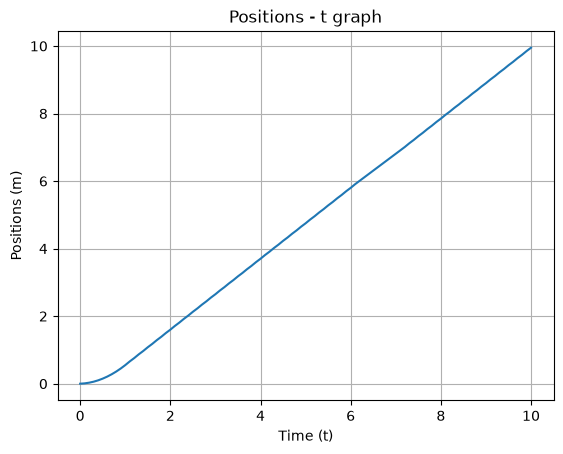

[np.float64(0.0), np.float64(0.010000000000000002), np.float64(0.030000000000000006), np.float64(0.06000000000000001), np.float64(0.10000000000000002), np.float64(0.15000000000000002), np.float64(0.21000000000000002), np.float64(0.28), np.float64(0.36000000000000004), np.float64(0.45000000000000007), np.float64(0.55), np.float64(0.66), np.float64(0.76), np.float64(0.87), np.float64(0.97), np.float64(1.08), np.float64(1.1800000000000002), np.float64(1.29), np.float64(1.3900000000000001), np.float64(1.5), np.float64(1.6), np.float64(1.71), np.float64(1.81), np.float64(1.92), np.float64(2.02), np.float64(2.13), np.float64(2.23), np.float64(2.34), np.float64(2.44), np.float64(2.55), np.float64(2.65), np.float64(2.76), np.float64(2.86), np.float64(2.9699999999999998), np.float64(3.07), np.float64(3.1799999999999997), np.float64(3.28), np.float64(3.3899999999999997), np.float64(3.4899999999999998), np.float64(3.5999999999999996), np.float64(3.6999999999999997), np.float64(3.8099999999999996)

In [12]:
plt.plot(times, positions)
plt.xlabel("Time (t)")
plt.ylabel("Positions (m)")
plt.title("Positions - t graph")
plt.grid()
plt.show()
print(positions)
print(done)

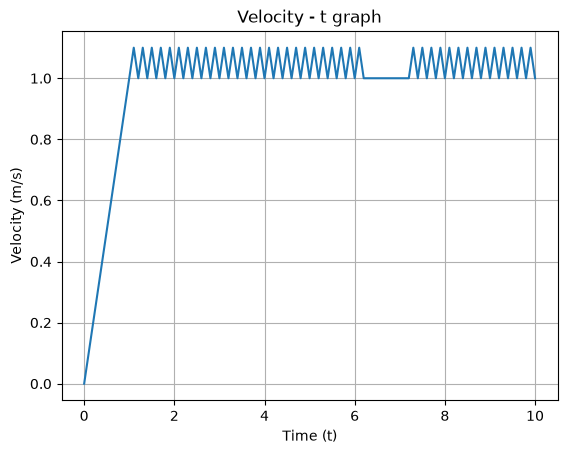

[np.float64(0.0), np.float64(0.1), np.float64(0.2), np.float64(0.30000000000000004), np.float64(0.4), np.float64(0.5), np.float64(0.6), np.float64(0.7), np.float64(0.7999999999999999), np.float64(0.8999999999999999), np.float64(0.9999999999999999), np.float64(1.0999999999999999), np.float64(0.9999999999999999), np.float64(1.0999999999999999), np.float64(0.9999999999999999), np.float64(1.0999999999999999), np.float64(0.9999999999999999), np.float64(1.0999999999999999), np.float64(0.9999999999999999), np.float64(1.0999999999999999), np.float64(0.9999999999999999), np.float64(1.0999999999999999), np.float64(0.9999999999999999), np.float64(1.0999999999999999), np.float64(0.9999999999999999), np.float64(1.0999999999999999), np.float64(0.9999999999999999), np.float64(1.0999999999999999), np.float64(0.9999999999999999), np.float64(1.0999999999999999), np.float64(0.9999999999999999), np.float64(1.0999999999999999), np.float64(0.9999999999999999), np.float64(1.0999999999999999), np.float64(0.99

In [13]:
plt.plot(times, velocities)
plt.xlabel("Time (t)")
plt.ylabel("Velocity (m/s)")
plt.title("Velocity - t graph")
plt.grid()
plt.show()
print(velocities)

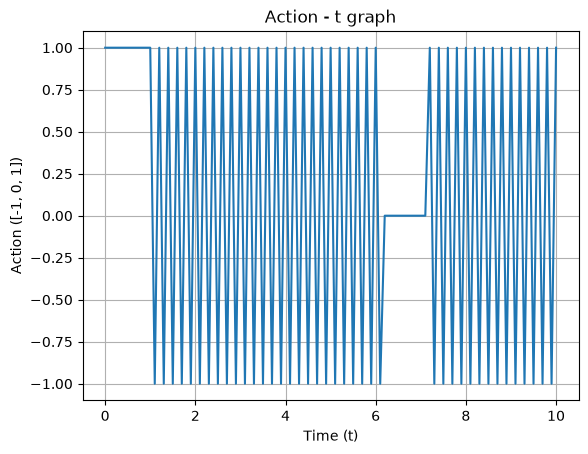

[]


In [ ]:
plt.plot(times, actions_log)
plt.xlabel("Time (t)")
plt.ylabel("Action ([-1, 0, 1])")
plt.title("Actions - t graph")
plt.grid()
plt.show()
print(actions)

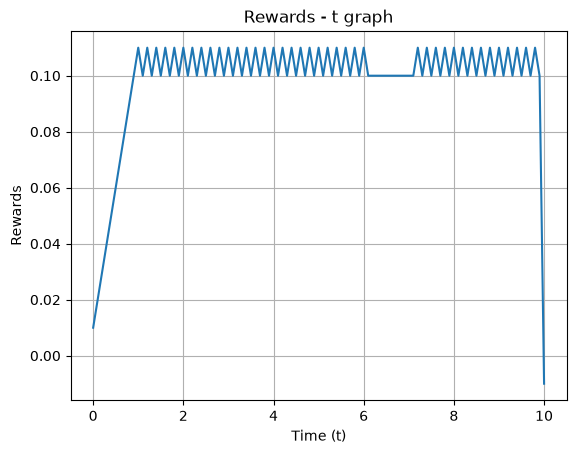

[0.009999999999999787, 0.019999999999999574, 0.030000000000001137, 0.03999999999999915, 0.05000000000000071, 0.0600000000000005, 0.06999999999999851, 0.08000000000000007, 0.08999999999999986, 0.10000000000000142, 0.10999999999999943, 0.09999999999999964, 0.10999999999999943, 0.10000000000000142, 0.10999999999999943, 0.09999999999999964, 0.10999999999999943, 0.10000000000000142, 0.10999999999999943, 0.09999999999999964, 0.11000000000000121, 0.09999999999999964, 0.10999999999999943, 0.09999999999999964, 0.11000000000000032, 0.10000000000000053, 0.10999999999999943, 0.09999999999999964, 0.11000000000000032, 0.10000000000000053, 0.10999999999999943, 0.09999999999999964, 0.11000000000000032, 0.10000000000000053, 0.10999999999999943, 0.09999999999999964, 0.11000000000000032, 0.10000000000000053, 0.10999999999999943, 0.09999999999999964, 0.11000000000000032, 0.10000000000000053, 0.10999999999999943, 0.09999999999999964, 0.11000000000000032, 0.09999999999999964, 0.11000000000000032, 0.09999999

In [16]:
plt.plot(times, rewards)
plt.xlabel("Time (t)")
plt.ylabel("Rewards")
plt.title("Rewards - t graph")
plt.grid()
plt.show()
print(rewards)